In [1]:
#Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="darkgrid")

print("All libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully


In [3]:
import os

# This shows where Jupyter thinks we currently are
print("Current directory:", os.getcwd())

# Let's find the events.csv wherever it is
for root, dirs, files in os.walk('C:/'):
    for file in files:
        if file == 'events.csv':
            print("Found at:", os.path.join(root, file))
    # Skip unnecessary folders to keep it fast
    dirs[:] = [d for d in dirs if d not in ['Windows', 'Program Files', 'Program Files (x86)', '$Recycle.Bin']]

Current directory: C:\Project(CSE_155)\retail-digital-twin
Found at: C:/Project(CSE_155)\retail-digital-twin\datasets\raw\events.csv


In [7]:
#Cell 2 — Load the Data
import os
os.chdir('C:/Project(CSE_155)/retail-digital-twin')

# Load all datasets
events = pd.read_csv('datasets/raw/events.csv')
item_props1 = pd.read_csv('datasets/raw/item_properties_part1.csv')
item_props2 = pd.read_csv('datasets/raw/item_properties_part2.csv')
category_tree = pd.read_csv('datasets/raw/category_tree.csv')

print(f"Events shape: {events.shape}")
print(f"Item Properties Part 1 shape: {item_props1.shape}")
print(f"Item Properties Part 2 shape: {item_props2.shape}")
print(f"Category Tree shape: {category_tree.shape}")


Events shape: (2756101, 5)
Item Properties Part 1 shape: (10999999, 4)
Item Properties Part 2 shape: (9275903, 4)
Category Tree shape: (1669, 2)


In [8]:
#Cell 3 — First Look at Events
print("=== EVENTS DATASET ===")
print(events.head(10))
print("\nColumn names:", events.columns.tolist())
print("\nData types:\n", events.dtypes)
print("\nNull values:\n", events.isnull().sum())

=== EVENTS DATASET ===
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
5  1433224086234     972639  view   22556            NaN
6  1433221923240     810725  view  443030            NaN
7  1433223291897     794181  view  439202            NaN
8  1433220899221     824915  view  428805            NaN
9  1433221204592     339335  view   82389            NaN

Column names: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']

Data types:
 timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64
dtype: object

Null values:
 timestamp              0
visitorid              0
event                  0
itemid                 0
tran

In [9]:
#Cell 4 — Convert Timestamp
# Timestamps are in milliseconds in this dataset
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.day_name()

print("Timestamp converted successfully")
print(events[['timestamp', 'datetime', 'date', 'hour', 'dayofweek']].head())

Timestamp converted successfully
       timestamp                datetime        date  hour dayofweek
0  1433221332117 2015-06-02 05:02:12.117  2015-06-02     5   Tuesday
1  1433224214164 2015-06-02 05:50:14.164  2015-06-02     5   Tuesday
2  1433221999827 2015-06-02 05:13:19.827  2015-06-02     5   Tuesday
3  1433221955914 2015-06-02 05:12:35.914  2015-06-02     5   Tuesday
4  1433221337106 2015-06-02 05:02:17.106  2015-06-02     5   Tuesday


=== EVENT TYPE COUNTS ===
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Total events: 2,756,101
Unique visitors: 1,407,580
Unique items: 235,061


C:\Users\Dell\AppData\Local\Temp\ipykernel_42384\2224794359.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')


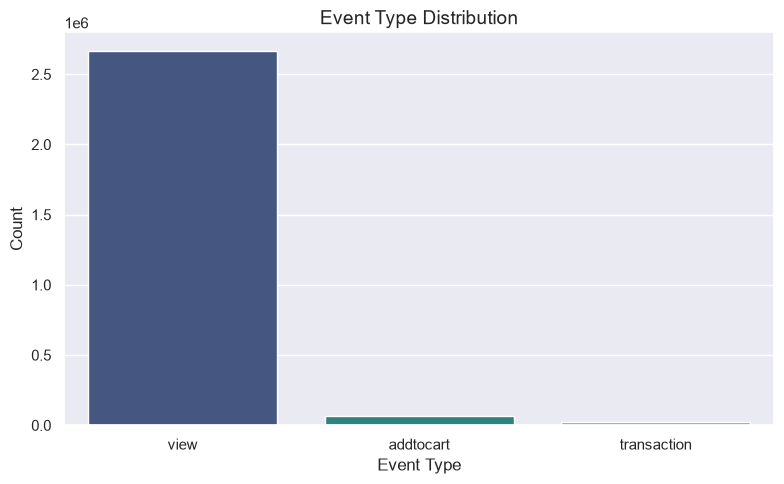

Plot saved to research/


In [12]:
#Cell 5 — Event Type Distribution
print("=== EVENT TYPE COUNTS ===")
event_counts = events['event'].value_counts()
print(event_counts)
print(f"\nTotal events: {len(events):,}")
print(f"Unique visitors: {events['visitorid'].nunique():,}")
print(f"Unique items: {events['itemid'].nunique():,}")

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')
plt.title('Event Type Distribution', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Event Type')
plt.tight_layout()
plt.savefig('research/event_distribution.png')
plt.show()
print("Plot saved to research/")

In [14]:
#Cell 6 — Conversion Funnel
views = event_counts.get('view', 0)
addtocart = event_counts.get('addtocart', 0)
transaction = event_counts.get('transaction', 0)

view_to_cart = (addtocart / views) * 100
cart_to_buy = (transaction / addtocart) * 100
view_to_buy = (transaction / views) * 100

print("=== CONVERSION FUNNEL ===")
print(f"Views:              {views:,}")
print(f"Add to Cart:        {addtocart:,}")
print(f"Transactions:       {transaction:,}")
print(f"\nView → Cart rate:   {view_to_cart:.2f}%")
print(f"Cart → Buy rate:    {cart_to_buy:.2f}%")
print(f"View → Buy rate:    {view_to_buy:.2f}%")

=== CONVERSION FUNNEL ===
Views:              2,664,312
Add to Cart:        69,332
Transactions:       22,457

View → Cart rate:   2.60%
Cart → Buy rate:    32.39%
View → Buy rate:    0.84%


In [15]:
#7 Per-user event counts
user_behavior = events.groupby(['visitorid', 'event']).size().unstack(fill_value=0)

# Rename columns safely
user_behavior.columns = [str(col) for col in user_behavior.columns]

if 'view' not in user_behavior.columns:
    user_behavior['view'] = 0
if 'addtocart' not in user_behavior.columns:
    user_behavior['addtocart'] = 0
if 'transaction' not in user_behavior.columns:
    user_behavior['transaction'] = 0

user_behavior = user_behavior.reset_index()
user_behavior.columns.name = None

print("=== USER BEHAVIOR SUMMARY ===")
print(user_behavior.describe())
print(f"\nUsers who only viewed:        {len(user_behavior[user_behavior['transaction'] == 0]):,}")
print(f"Users who purchased at least once: {len(user_behavior[user_behavior['transaction'] > 0]):,}")

=== USER BEHAVIOR SUMMARY ===
        visitorid   addtocart  transaction        view
count 1407580.000 1407580.000  1407580.000 1407580.000
mean   703789.500       0.049        0.016       1.893
std    406333.490       1.165        0.826      10.994
min         0.000       0.000        0.000       0.000
25%    351894.750       0.000        0.000       1.000
50%    703789.500       0.000        0.000       1.000
75%   1055684.250       0.000        0.000       2.000
max   1407579.000     719.000      559.000    6479.000

Users who only viewed:        1,395,861
Users who purchased at least once: 11,719


In [16]:
#8 # Engagement score = weighted sum of actions
user_behavior['engagement_score'] = (
    user_behavior['view'] * 1 +
    user_behavior['addtocart'] * 3 +
    user_behavior['transaction'] * 5
)

top_users = user_behavior.sort_values('engagement_score', ascending=False).head(10)

print("=== TOP 10 MOST ENGAGED USERS ===")
print(top_users[['visitorid', 'view', 'addtocart', 'transaction', 'engagement_score']])

=== TOP 10 MOST ENGAGED USERS ===
         visitorid  view  addtocart  transaction  engagement_score
1150086    1150086  6479        719          559             11431
530559      530559  3623        419          286              6310
152963      152963  2304        371          349              5162
684514      684514  1826        231          189              3464
76757        76757  1402        296          185              3215
861299      861299  1573        230          188              3203
163561      163561  2194        124           92              3026
371606      371606  2141        110           94              2941
286616      286616  2057        120           75              2792
895999      895999  2368         56           50              2786


=== TOP 10 MOST VIEWED ITEMS ===
itemid
187946    3410
461686    2539
5411      2325
370653    1854
219512    1740
298009    1642
96924     1633
309778    1565
257040    1531
384302    1528
Name: count, dtype: int64

=== TOP 10 MOST PURCHASED ITEMS ===
itemid
461686    133
119736     97
213834     92
7943       46
312728     46
445351     45
48030      41
420960     38
248455     38
17478      37
Name: count, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_42384\3819509142.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_viewed.values, y=top_viewed.index.astype(str), ax=axes[0], palette='Blues_r')
C:\Users\Dell\AppData\Local\Temp\ipykernel_42384\3819509142.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bought.values, y=top_bought.index.astype(str), ax=axes[1], palette='Greens_r')


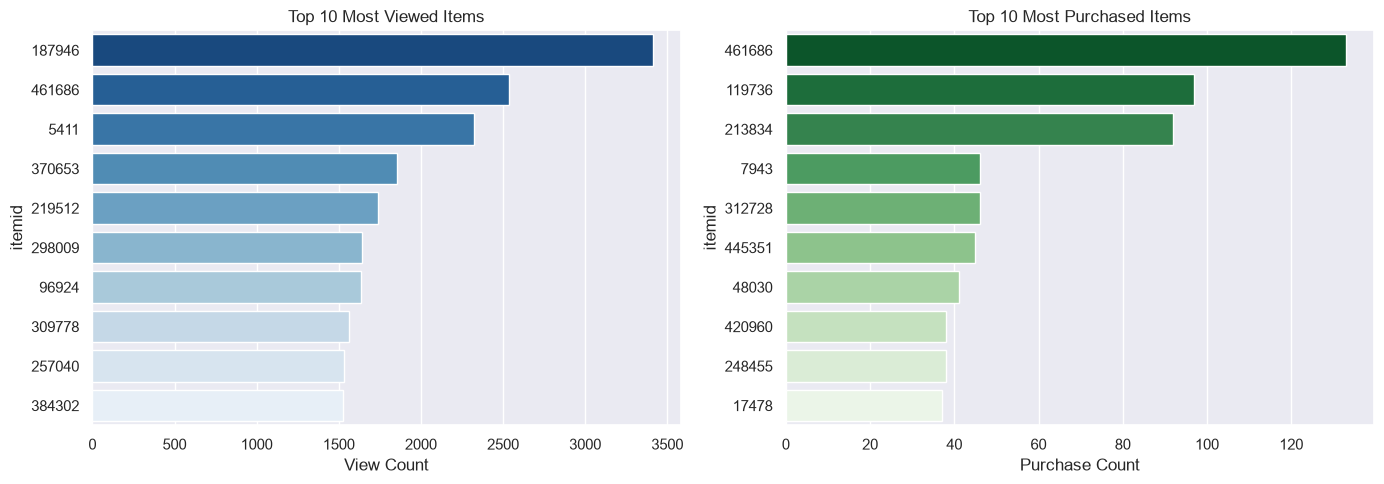

In [22]:
#9 # Most viewed items
top_viewed = events[events['event'] == 'view']['itemid'].value_counts().head(10)
top_bought = events[events['event'] == 'transaction']['itemid'].value_counts().head(10)

print("=== TOP 10 MOST VIEWED ITEMS ===")
print(top_viewed)

print("\n=== TOP 10 MOST PURCHASED ITEMS ===")
print(top_bought)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_viewed.values, y=top_viewed.index.astype(str), ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Most Viewed Items')
axes[0].set_xlabel('View Count')

sns.barplot(x=top_bought.values, y=top_bought.index.astype(str), ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Most Purchased Items')
axes[1].set_xlabel('Purchase Count')

plt.tight_layout()
plt.savefig('research/top_items.png')
plt.show()

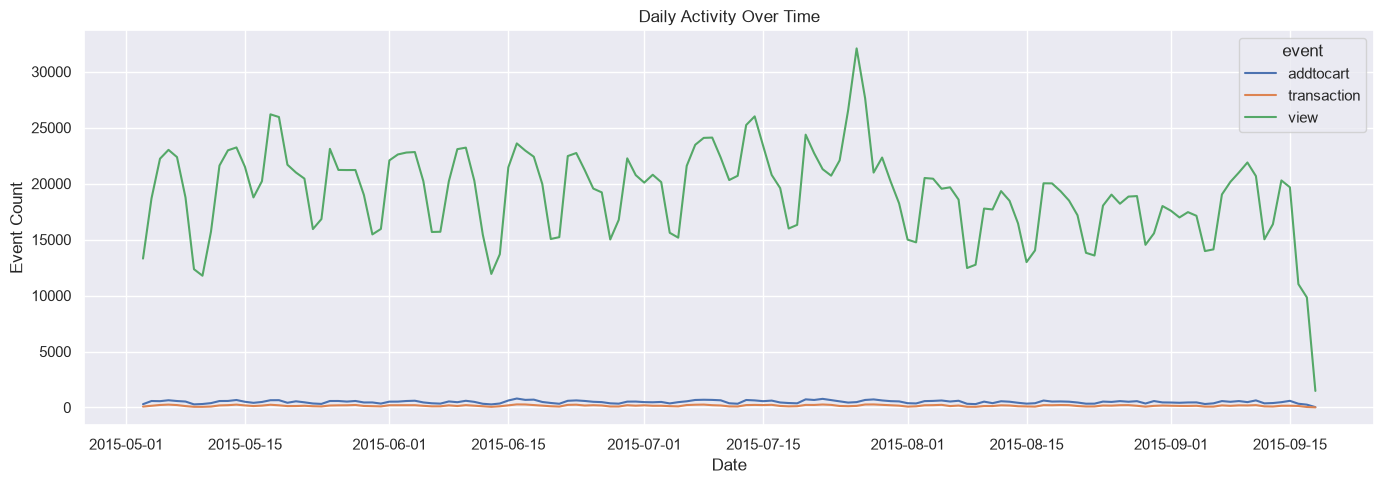

In [23]:
#10 
daily_activity = events.groupby(['date', 'event']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
daily_activity.plot(ax=plt.gca())
plt.title('Daily Activity Over Time')
plt.ylabel('Event Count')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('research/daily_activity.png')
plt.show()

In [25]:
#11 # Save for use in next module
user_behavior.to_csv('datasets/processed/user_behavior.csv', index=False)
print(f"Saved user_behavior.csv with {len(user_behavior):,} users")
print("Columns saved:", user_behavior.columns.tolist())

Saved user_behavior.csv with 1,407,580 users
Columns saved: ['visitorid', 'addtocart', 'transaction', 'view', 'engagement_score']


In [28]:
#12
print("=" * 50)
print("EDA COMPLETE — SUMMARY")
print("=" * 50)
print(f"Total events analyzed:     {len(events):,}")
print(f"Unique customers:          {events['visitorid'].nunique():,}")
print(f"Unique products:           {events['itemid'].nunique():,}")
print(f"Date range:                {events['date'].min()} → {events['date'].max()}")
print(f"View → Purchase rate:      {view_to_buy:.3f}%")
print(f"Processed file saved:      datasets/processed/user_behavior.csv")
print("=" * 50)
print("Ready for Module 2: Customer Digital Twin Engine")

EDA COMPLETE — SUMMARY
Total events analyzed:     2,756,101
Unique customers:          1,407,580
Unique products:           235,061
Date range:                2015-05-03 → 2015-09-18
View → Purchase rate:      0.843%
Processed file saved:      datasets/processed/user_behavior.csv
Ready for Module 2: Customer Digital Twin Engine
